<a target="_blank" href="https://colab.research.google.com/github/LSSTC-DSFP/Session-25/tree/main/Day1/SupervisedML.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Supervised Machine Learning

#### LSSTC DSFP Session 25

#### Rob Morgan

## Earlier

Entering this lecture, we've covered a couple important concepts:

- ML is a **tool** for identifying patterns in training data
- Based on the patterns, astronomers can make predictions about new data to further analyses

## This Talk

- How to use your tools
- How to fine tune your tools
- How to measure the performance of your tools


Specifically, that means we're going to dive into the following jargony words:

- training data, testing data, and stratification
- confusion matrices
- cross validation
- under- and over-fitting

# Learn by Doing

Everyone learns classification with the Iris Dataset.

Instead, let's classify supernovae!

![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQ0nanF0IcGJ47ydO6wPLORrI34wkeVYVIATw&s)

Image credit: http://astronomy.nmsu.edu/tharriso/ast110/class20.html

To simplify things, let's use just two features:
- dimming time
- color

In [2]:
# For folks at home, this is a hidden cell where I completely make up the data
# for the example by augmenting the Iris Dataset and pretending it's supernovae.
# Like I said, "Everyone learns classification with the Iris Dataset.""

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

def load_sne_data(training_data=True, validation_data=False, two_class=False):

  X, y = load_iris(return_X_y=True)

  # Pretend 10x sepal length (cm) = 10x dimming time (days)
  X[:,0] *= 10

  # Pretend sepal width (cm) = g-i color (mag)
  X[:,1] *= -1

  # Pretend the different iris species are types of SNe. We'll just say
  # 0 = SN-Ia, 1 = SN-Ibc, 2 = SN-II
  if two_class:
    y = np.array([0 if label==0 else 1 for label in y])

  X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y)

  if training_data and not validation_data:
    return X_train[:,:2], y_train

  if not training_data and validation_data:
    return X_test[:,:2], y_test

  return X[:,:2], y



In [3]:
X, y = load_sne_data()
print(X[0:5], y)
print(X.shape, y.shape)

[[63.  -3.4]
 [51.  -3.5]
 [58.  -2.7]
 [52.  -2.7]
 [46.  -3.4]] [2 0 2 1 0 0 0 2 0 0 1 0 1 1 2 2 0 0 2 0 2 0 0 2 0 1 2 1 0 1 0 2 1 2 1 0 2
 0 2 0 1 1 0 2 1 1 0 2 1 2 0 1 0 2 1 1 1 1 1 1 2 1 2 2 0 2 1 1 2 0 2 2 2 0
 2 0 0 2 2 2 0 1 2 2 0 1 1 1 1 1 0 2 1 2 0 0 1 0 1 0]
(100, 2) (100,)


In [4]:
import matplotlib.pyplot as plt

def visualize_sn_data(X, y):

  labels = ['Ia', 'Ibc', 'II']
  fig, ax = plt.subplots(figsize=(10, 8))
  for target, label in zip(range(3), labels):
      ax.scatter(X[y == target, 0], X[y == target, 1],
                color=f'C{target}', s=100,
                label=label, lw=0)
  ax.set_xlabel('Dimming Time (days)', fontsize=20)
  ax.set_ylabel('g-i Color (mag)', fontsize=20)
  ax.set_xlim(41, 79)
  ax.set_ylim(-4.2, -1.8)
  plt.xticks(fontsize=18)
  plt.yticks(fontsize=18)
  leg = plt.legend(title='SN Type', fontsize=18)
  plt.setp(leg.get_title(), fontsize=20)
  plt.show()
  plt.close()

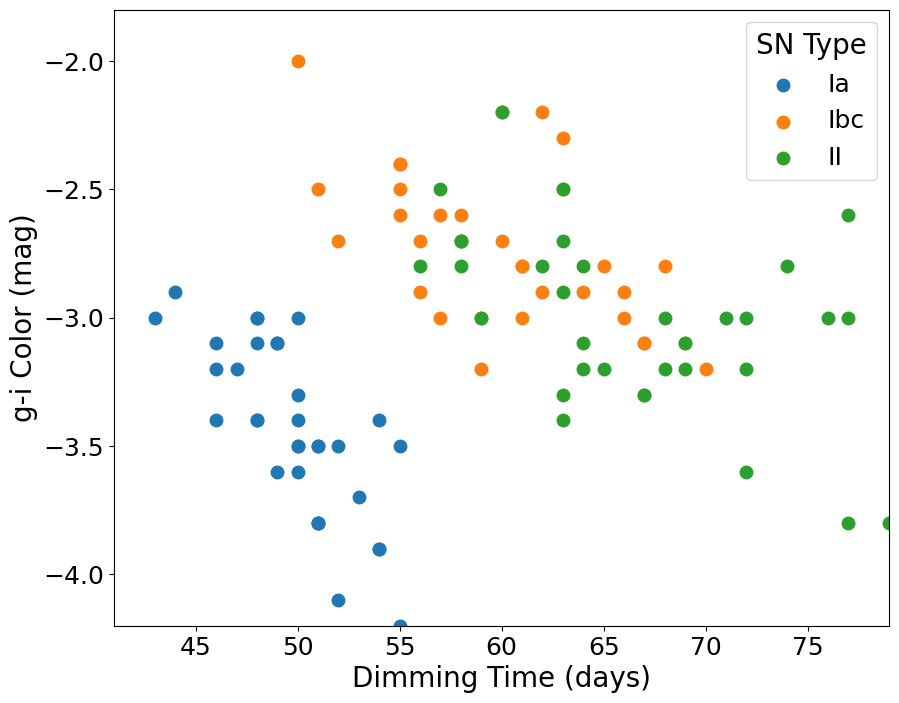

In [5]:
visualize_sn_data(X, y)

Before we get to the artificial intelligence, let's start with some good old natural intelligence.

I'm going to attempt a classification scheme with a couple rules:

- If `dimming_time > 59.5`: SN-II
- Else if `color < -3.05`: SN-Ia
- Else: SN-Ibc

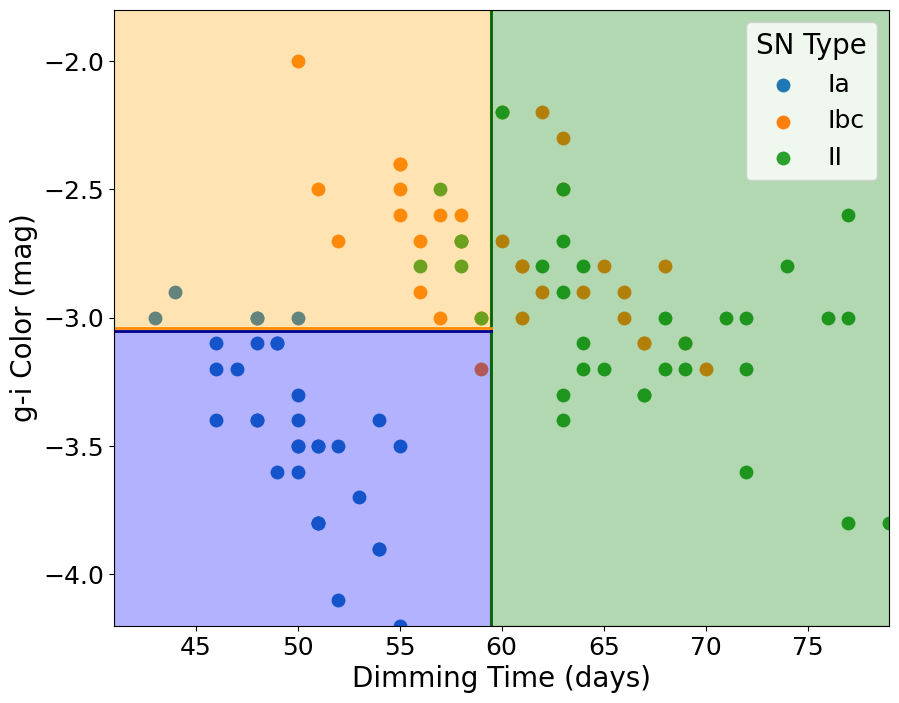

In [6]:
def visualize_sn_data_with_rules(X, y):

  labels = ['Ia', 'Ibc', 'II']
  fig, ax = plt.subplots(figsize=(10, 8))
  for target, label in zip(range(3), labels):
      ax.scatter(X[y == target, 0], X[y == target, 1],
                color=f'C{target}', s=100,
                label=label, lw=0)


  ax.axvline(x=59.5, color='darkgreen', lw=2)
  ax.axvspan(xmin=59.5, xmax=90, color='green', alpha=0.3)


  ax.plot([40, 59.5], [-3.05, -3.05], color='darkblue', lw=2)
  ax.plot([40, 59.5], [-3.04, -3.04], color='darkorange', lw=2)

  ax.axhspan(ymin=-4.3, ymax=-3.05, xmin=0, xmax=0.485, color='blue', alpha=0.3)
  ax.axhspan(ymin=-3.04, ymax=-1.7, xmin=0, xmax=0.485, color='orange', alpha=0.3)


  ax.set_xlabel('Dimming Time (days)', fontsize=20)
  ax.set_ylabel('g-i Color (mag)', fontsize=20)
  ax.set_xlim(41, 79)
  ax.set_ylim(-4.2, -1.8)
  plt.xticks(fontsize=18)
  plt.yticks(fontsize=18)
  leg = plt.legend(title='SN Type', fontsize=18)
  plt.setp(leg.get_title(), fontsize=20)
  plt.show()
  plt.close()

visualize_sn_data_with_rules(X, y)

In [11]:
class SnClassifier:

  @staticmethod
  def predict(X):

    predictions = []
    for sn in X:
      label = None
      if sn[0] > 59.5:
        label = 1
      elif sn[1] < -3.05:
        label = 0
      else:
        label = 2

      predictions.append(label)

    return np.array(predictions)

X, y = load_sne_data()

clf = SnClassifier()
y_pred = clf.predict(X)




              precision    recall  f1-score   support

           0       0.97      0.85      0.91        34
           1       0.40      0.55      0.46        33
           2       0.24      0.18      0.21        33

    accuracy                           0.53       100
   macro avg       0.54      0.53      0.52       100
weighted avg       0.54      0.53      0.53       100



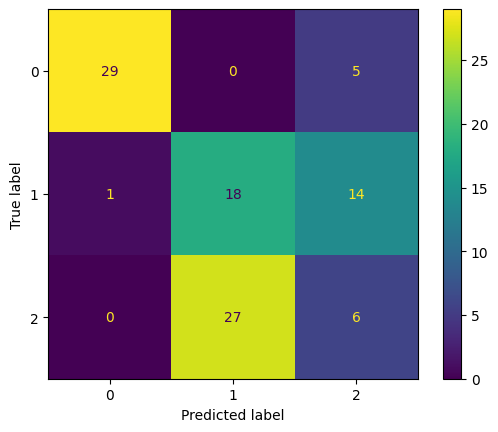

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print(classification_report(y, y_pred))

ConfusionMatrixDisplay(confusion_matrix(y, y_pred)).plot()
plt.show()

## Natural Intelligence -> Artificial Intelligence

I don't want to set the classification rules, I want the machines to do it for me.

How can we program the machines to find optimal rules?

Consider an algorithm like this:

1. For 100 values of `dimming_time` and 100 values of `color`, set a single classification rule at that value. Compute the accuracy of each rule and keep the best one. This is a `depth` of 1.
1. In each of the 2 halves, again search values of `dimming_time` and `color`. Compute the accuracy of all splits and keep the best ones. These rules have a `depth` of 2.
1. In each of the 4 quadrants, ...
1. Repeat until a prespecified maximum depth.

This is machine learning: an algorithm to determine rules based on data.

In [13]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(max_depth=2)
clf.fit(X, y)

DecisionTreeClassifier(max_depth=2)

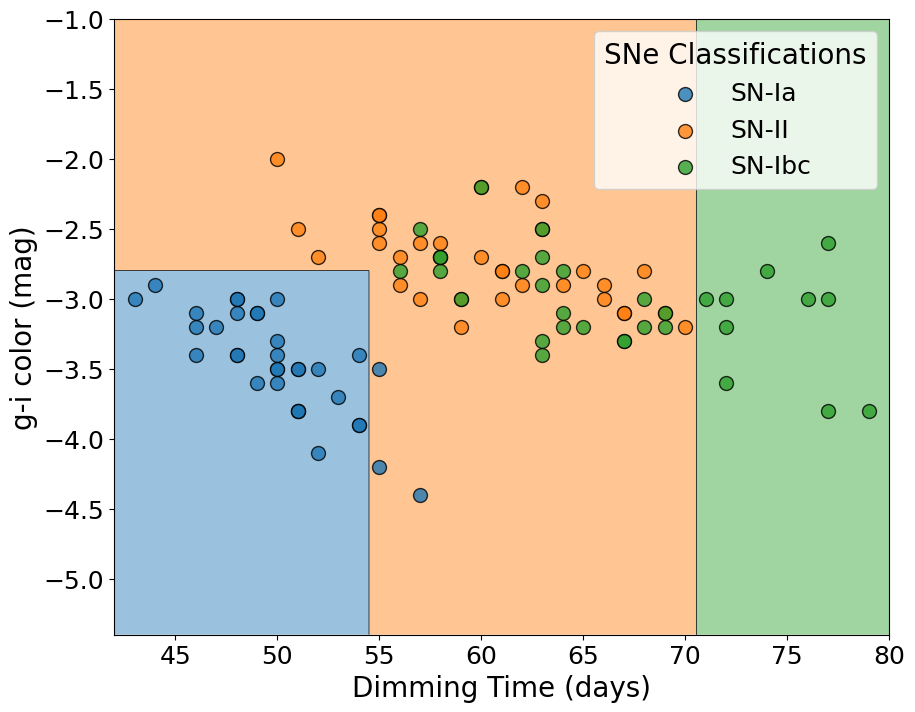

In [14]:
from mlxtend.plotting import plot_decision_regions

def plot_tree_decision_regions(clf: DecisionTreeClassifier, X, y):

  labels = ['SN-Ia', 'SN-II', 'SN-Ibc']
  fig, ax = plt.subplots(figsize=(10, 8))
  with plt.style.context({'lines.markersize': 10}):
      plot_decision_regions(X, y, clf, colors='C0,C1,C2', markers='ooo',
                            hide_spines=False, ax=ax)
  ax.set_xlabel('Dimming Time (days)', fontsize=20)
  ax.set_ylabel('g-i color (mag)', fontsize=20)
  plt.xticks(fontsize=18)
  plt.yticks(fontsize=18)
  leg = plt.legend(title='SNe Classifications', fontsize=18)
  for idx, label in enumerate(labels):
      leg.get_texts()[idx].set_text(label)
  plt.setp(leg.get_title(), fontsize=20)
  plt.show()
  plt.close()

plot_tree_decision_regions(clf, X, y)

In [15]:
y_pred = clf.predict(X)

print(classification_report(y, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.91      0.95        34
           1       0.56      1.00      0.72        33
           2       1.00      0.30      0.47        33

    accuracy                           0.74       100
   macro avg       0.85      0.74      0.71       100
weighted avg       0.85      0.74      0.71       100



## But what happens when we get new data?

The whole reason we're developing a classifier is to one day be able to use it on new data to make decisions.

Should I spend telescope time on getting more data? If it's a SN-Ia and you are a cosmologist, probably!

But that relies on your classifier performing well on unseen data.

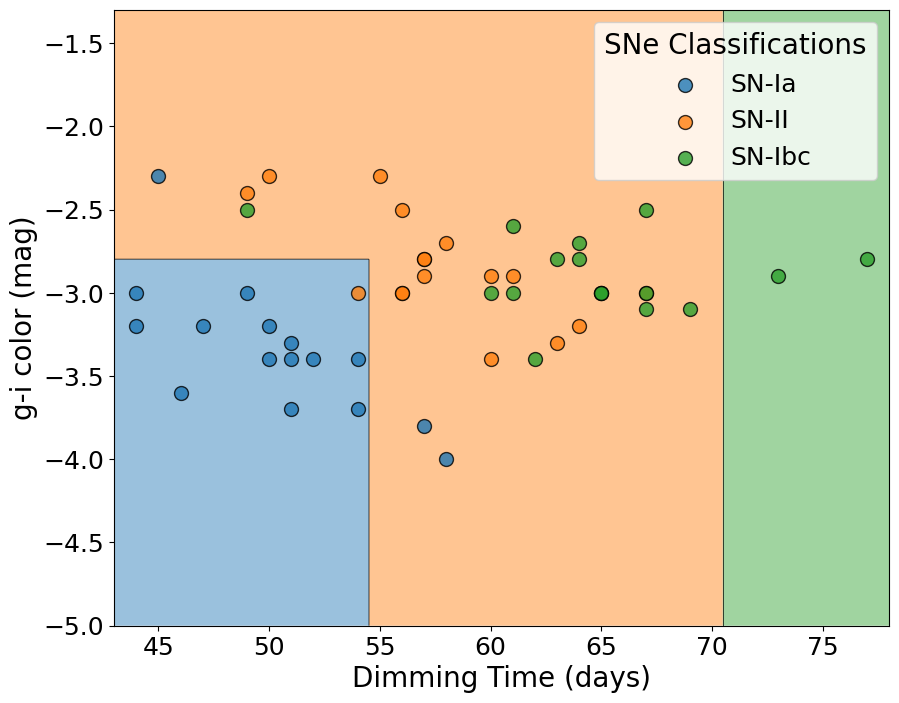

In [16]:
new_X, new_y = load_sne_data(training_data=False, validation_data=True)

plot_tree_decision_regions(clf, new_X, new_y)

In [17]:
print(classification_report(new_y, clf.predict(new_X)))


              precision    recall  f1-score   support

           0       0.93      0.81      0.87        16
           1       0.47      0.94      0.63        17
           2       1.00      0.12      0.21        17

    accuracy                           0.62        50
   macro avg       0.80      0.62      0.57        50
weighted avg       0.80      0.62      0.56        50



## Validation and Test Sets

It's best practice to hold back sections of your labeled data for evaluating your trained classifier.

`scikit-learn` has convenient functionalities to help with this.

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y)
```

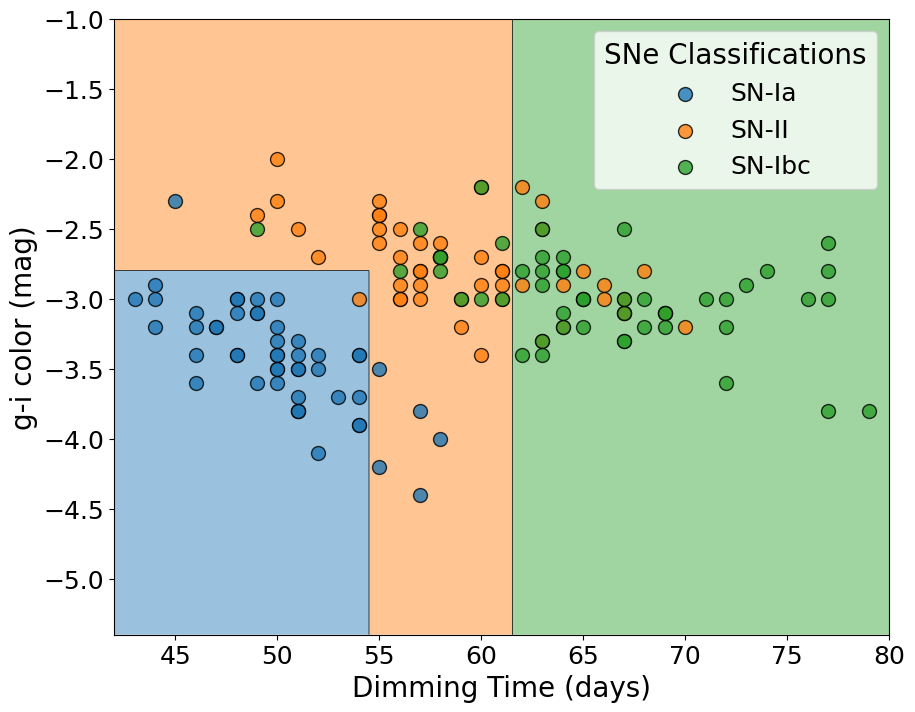

              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.44      0.40      0.42        10
           2       0.58      0.70      0.64        10

    accuracy                           0.63        30
   macro avg       0.64      0.63      0.63        30
weighted avg       0.64      0.63      0.63        30



In [18]:
from sklearn.model_selection import train_test_split

all_X, all_y = load_sne_data(training_data=True, validation_data=True)

X_train, X_test, y_train, y_test = train_test_split(
    all_X, all_y, test_size=0.2, random_state=42, stratify=all_y)

clf.fit(X_train, y_train)

plot_tree_decision_regions(clf, all_X, all_y)

print(classification_report(y_test, clf.predict(X_test)))


## Confidence in Model Evaluation

In our last result, we got an accuracy of 63%.

That accuracy is a function of which data we trained on and which data we held back for evaluation.

What if I'd selected different examples to constitute the training and test sets?

Would the accuracy change?

Would I classify SNe differently as a result?

Cross validation helps us quantify the spread of our predictions.

![](https://scikit-learn.org/stable/_images/grid_search_cross_validation.png)

And yes, there is a convenient way to do this in `scikit-learn`.

In [19]:
from sklearn.model_selection import cross_validate

scores = cross_validate(clf, X_train, y_train,
                        scoring='accuracy', cv=10,
                        return_train_score=True)

print(scores.keys())
test_scores = scores['test_score']
train_scores = scores['train_score']
print(test_scores)
print(train_scores)

print('\n10-fold CV scores:')
print(f'training score = {np.mean(train_scores)} +/- {np.std(train_scores)}')
print(f'validation score = {np.mean(test_scores)} +/- {np.std(test_scores)}')

dict_keys(['fit_time', 'score_time', 'test_score', 'train_score'])
[0.83333333 0.91666667 0.83333333 0.75       0.75       0.66666667
 0.83333333 0.66666667 0.83333333 0.75      ]
[0.80555556 0.7962963  0.80555556 0.80555556 0.81481481 0.82407407
 0.80555556 0.82407407 0.80555556 0.81481481]

10-fold CV scores:
training score = 0.8101851851851851 +/- 0.008536615238234145
validation score = 0.7833333333333333 +/- 0.07637626158259735


## Fine Tuning

How did we land on a `max_depth` of 3?

Are there other settings for the classifier we have control over?

Can these things be handled programmatically?

# Yes

## Hyperparameter Tuning via GridSearch

The procedure is:
1. Iterate over all parameter settings
1. Train a classifier, evaluate on unseen data
1. Keep track of parameter settings that yield the highest performance
    - Bonus: use cross validation when evaluating to limit bias

Goal: avoid under- and over-fitting

![](https://scikit-learn.org/stable/_images/sphx_glr_plot_underfitting_overfitting_001.png)



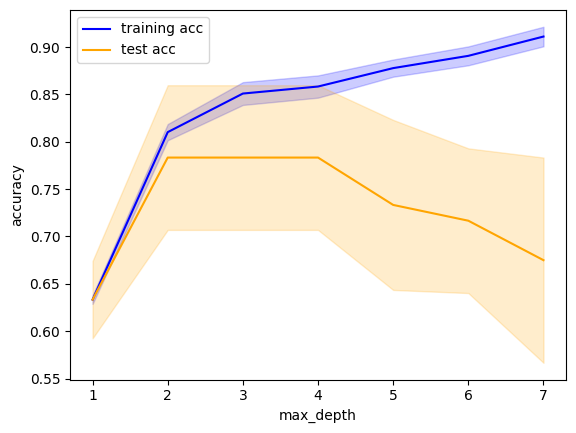

In [21]:
train_acc, test_acc, train_unc, test_unc = [], [], [], []

max_depths = list(range(1, 8))
for max_depth in max_depths:

  clf = DecisionTreeClassifier(max_depth=max_depth)

  scores = cross_validate(
      clf,
      X_train,
      y_train,
      scoring='accuracy',
      cv=10,
      return_train_score=True)

  train_acc.append(np.mean(scores['train_score']))
  train_unc.append(np.std(scores['train_score']))
  test_acc.append(np.mean(scores['test_score']))
  test_unc.append(np.std(scores['test_score']))

plt.figure()
plt.plot(max_depths, train_acc, color='blue', label='training acc')
plt.plot(max_depths, test_acc, color='orange', label='test acc')
plt.fill_between(max_depths, np.array(train_acc) - np.array(train_unc), np.array(train_acc) + np.array(train_unc), color='blue', alpha=0.2)
plt.fill_between(max_depths, np.array(test_acc) - np.array(test_unc), np.array(test_acc) + np.array(test_unc), color='orange', alpha=0.2)
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.legend()
plt.show()
plt.close()



# Is there a convenient `scikit-learn` way to do that?

You betcha.

In practice you may even want to optimize multiple hyperparamters.


In [22]:
from sklearn.model_selection import GridSearchCV

# Instantiate a model
clf = DecisionTreeClassifier()

# Specify hyperparameter values to test
parameters = {'max_depth': range(1, 20),
              'criterion': ['gini', 'entropy'],
              'min_samples_leaf': range(1, 4)}

# Run grid search
gridsearch = GridSearchCV(clf, parameters, scoring='accuracy', cv=10)
gridsearch.fit(X_train, y_train)

# Get best model
print(f'gridsearch.best_params_ = {gridsearch.best_params_}')


gridsearch.best_params_ = {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 3}


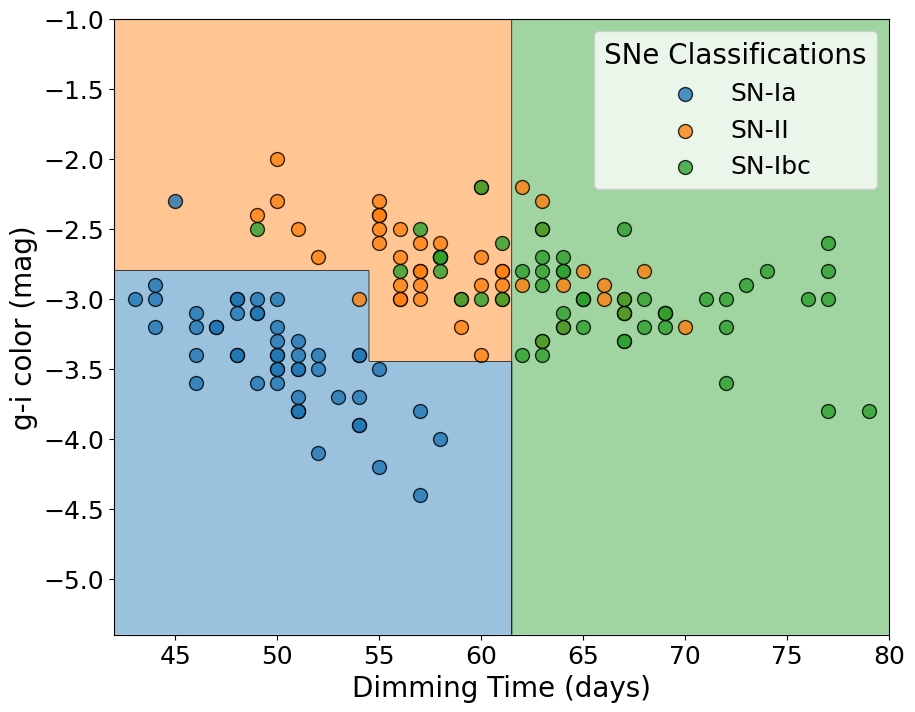

              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       0.57      0.40      0.47        10
           2       0.58      0.70      0.64        10

    accuracy                           0.70        30
   macro avg       0.69      0.70      0.69        30
weighted avg       0.69      0.70      0.69        30



In [23]:
clf = DecisionTreeClassifier(**gridsearch.best_params_)
clf.fit(X_train, y_train)

plot_tree_decision_regions(clf, all_X, all_y)

print(classification_report(y_test, clf.predict(X_test)))

## A Supervised ML Workflow

1. Select / construct the features of interest from your dataset
2. Set aside ~10-20% of your data for final testing
3. Select your algorithm
4. Set your hyperparameters with cross validation and grid search
5. Train your classifier on the training data
6. Evaluate your classifer on the final testing data

![](https://scikit-learn.org/stable/_images/grid_search_workflow.png)


```python
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Construct features and labels
X = ...
y = ...

# Separate training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Instantiate a model
clf = DecisionTreeClassifier()

# Specify hyperparameter values to test
parameters = {'max_depth': range(1, 20),
              'criterion': ['gini', 'entropy'],
              'min_samples_leaf': range(1, 4)}

# Run grid search
gridsearch = GridSearchCV(clf, parameters, scoring='accuracy', cv=10)
gridsearch.fit(X_train, y_train)

# Evaluate performance
print(classification_report(y_test, gridsearch.best_estimator_.predict(X_test)))

```

![](https://scikit-learn.org/stable/_images/grid_search_workflow.png)